# Module_1: *(Faye)*

## Team Members:
Claire and Faye

## Project Title:
pTAU Concentration in Donors With and Without Dementia

## Project Goal:
This project looks at whether donors with dementia have a different mean pTAU concentration than donors without dementia. I also compare female and male donors with dementia and look at whether amyloid-beta42 and pTAU are related. These proteins are involved in Alzheimer’s disease, but the dementia label in this data does not mean that every donor had Alzheimer’s.

I chose this question because tau changes are part of Alzheimer’s disease, so comparing pTAU by cognitive status can help explore whether the protein measurement is related to dementia in this sample. The sex comparison looks at another possible difference within the dementia group, and the scatter plot checks whether the two protein measurements tend to increase together. [11](https://www.nia.nih.gov/health/what-happens-brain-alzheimers-disease)

## Disease Background: 
* Prevalence & incidence 
    * Alzheimer’s is the most common cause of dementia and accounts for about 60–70% of dementia cases worldwide. In the United States, an estimated 7.4 million adults aged 65 and older have Alzheimer’s dementia in 2026. Prevalence is the number of people who have a disease, while incidence is the number of new cases over time. Both increase with age. [1](https://www.who.int/news-room/fact-sheets/detail/dementia) [2](https://www.alz.org/alzheimers-dementia/facts-figures)
* Economic burden
    * Alzheimer’s places a large financial burden on patients, families, and the health care system. In the United States, health care, long-term care, and hospice costs for people with Alzheimer’s and other dementias are expected to reach $409 billion in 2026. About $103 billion of this will be paid out of pocket. These costs do not include the unpaid care provided by family and friends. In 2025, unpaid caregivers provided more than 19 billion hours of care, valued at over $446 billion. This shows how much dementia care depends on families as well as paid services. [2](https://www.alz.org/alzheimers-dementia/facts-figures)
* Risk factors (genetic, lifestyle) 
    * Age is the biggest risk factor for Alzheimer’s, but genetics also play a role. The APOE ε4 gene variant increases a person’s risk, although having it does not mean they will develop Alzheimer’s. Rare changes in the APP, PSEN1, and PSEN2 genes can cause inherited Alzheimer’s that often starts before age 65. Lifestyle and health factors linked to Alzheimer’s or other dementias include physical inactivity, smoking, heavy drinking, high blood pressure, diabetes, and obesity. Managing these factors may help lower risk, but it cannot fully prevent the disease. [3](https://www.nia.nih.gov/health/alzheimers-disease-genetics-fact-sheet) [4](https://stacks.cdc.gov/view/cdc/118011)
* Societal determinants
    * A person’s living conditions and access to resources can affect their risk of Alzheimer’s and other dementias. Education may help the brain cope with changes caused by disease. Access to health care can help people manage conditions such as high blood pressure and identify memory problems earlier. Safe neighborhoods, healthy food, and places to exercise also make it easier to maintain healthy habits. Social isolation and loneliness are linked to a higher risk of dementia. Unequal access to these resources can contribute to differences in who develops dementia and who receives timely diagnosis and care. [5](https://www.cdc.gov/alzheimers-dementia/php/sdoh/index.html)
* Symptoms
    * Alzheimer’s symptoms usually start slowly and worsen over time. One of the first signs is difficulty remembering new information or recent events. A person may repeat questions, struggle to find words, lose track of plans, or get lost in familiar places. As the disease progresses, everyday activities like paying bills, getting dressed, and recognizing family members become harder. Some people also develop anxiety, agitation, sleep problems, or changes in behavior. In the later stages, people need help with most daily activities and may have difficulty speaking and swallowing. Symptoms and the speed of progression vary from person to person. [6](https://www.nia.nih.gov/health/alzheimers-and-dementia/alzheimers-disease-fact-sheet)
* Diagnosis
    * Doctors diagnose Alzheimer’s by looking at changes in memory, thinking, and daily functioning. They review the person’s medical history, ask about symptoms, and often speak with family members. Memory tests, physical exams, and lab tests help assess the symptoms and check for other possible causes. MRI or CT scans can show changes in the brain or identify other problems. More specific tests, such as amyloid PET scans, spinal fluid tests, and certain blood tests, can detect signs of Alzheimer’s-related proteins. These results are considered alongside the person’s symptoms and medical evaluation rather than used alone to make a diagnosis. [6](https://www.nia.nih.gov/health/alzheimers-and-dementia/alzheimers-disease-fact-sheet) [7](https://www.nia.nih.gov/health/alzheimers-symptoms-and-diagnosis/how-biomarkers-help-diagnose-dementia)


## Data-Set:
I used *Metadata and Protein Data for Module 1.csv*, which was provided for this assignment. There are 84 donors in the file. Of these, 42 had dementia and 42 did not. There are 51 female and 33 male donors, with ages at death from 65 to 102. In the dementia group, there are 27 female and 15 male donors. The study column lists 69 donors from ACT and 15 from ADRC Clinical Core. (Course CSV, n.d.; reference 15)

The data includes information about the donors, their cognitive status, and protein levels. My code uses donor ID, sex, cognitive status, pTAU, and amyloid-beta42. The protein concentrations are listed in pg/ug, or picograms per microgram. The CSV does not explain what the microgram measurement refers to or which lab test was used to measure the proteins.

The donor counts and age range match the published SEA-AD data set, which includes donated brains and clinical information. This suggests that the donor information came from SEA-AD. However, the class CSV does not give an original source or explain how its protein measurements were collected. The SEA-AD studies used brain tissue imaging and molecular methods, but I would need the class documentation to confirm the method and brain region for these specific measurements. [13](https://pmc.ncbi.nlm.nih.gov/articles/PMC11577961/) [14](https://doi.org/10.1038/s41593-024-01774-5)

## Data Analysis:
I used my Patient class to read the CSV and make an object for each donor. I sorted the donors from lowest to highest pTAU and filtered them by sex and cognitive status. Then I found the mean and sample standard deviation for each group.

I used independent, two-sided t-tests to compare donors with and without dementia and female and male donors with dementia. My code assumes equal variances for these tests. I used 0.05 as the cutoff for statistical significance. The bar graphs show the mean, and the error bars show plus and minus one standard deviation. These error bars show the spread of the data, not a confidence interval.

I also made a scatter plot using all 84 donors. Amyloid-beta42 is on the x-axis and pTAU is on the y-axis. I added a linear regression line and calculated R² to see how much of the variation in pTAU the line explains.

The code below can run from top to bottom. The CSV should be in the same folder as the notebook, and matplotlib and scipy need to be installed. All of the results and graphs below use the course CSV (reference 15).

In [1]:
#AI assistance acknowledgment: OpenAI's Codex helped me add things I did not
#know how to do: printing from the filter with print_patients, clearing the
#patient list before reloading, using utf-8-sig and newline="" to read the CSV,
#and using :.3f to display numbers to three decimal places. September 15, 2026.

import csv

#the code below defines the patient class and keeps a list of all patients
class Patient:
    all_patients = []

    #the constructor gives each patient their attributes
    def __init__(self, donor_id: str, sex: str, cognitive_status: str,
                 ptau: float, abeta42: float):
        self.donor_id = donor_id
        self.sex = sex
        self.cognitive_status = cognitive_status
        self.ptau = ptau
        self.abeta42 = abeta42
        Patient.all_patients.append(self)

    #the representer shows these attributes when a patient is printed
    def __repr__(self):
        return (f"{self.donor_id}: ({self.sex} | {self.cognitive_status} | "
                f"pTAU = {self.ptau:.3f} pg/ug | ABeta42 = {self.abeta42:.3f} pg/ug)")

    #this gets the pTAU concentration so the patients can be sorted
    def get_ptau(self):
        return self.ptau

    @classmethod
    def instantiate_from_csv(cls, filename: str):
        #the code below opens the .csv file and makes a list of its rows
        with open(filename, encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)
            rows_of_patients = list(reader)

        #this clears the list so loading the file again does not add duplicates
        cls.all_patients.clear()

        #the code below creates a patient object for each row
        for row in rows_of_patients:
            Patient(
                donor_id = row['Donor ID'],
                sex = row['Sex'],
                cognitive_status = row['Cognitive Status'],
                ptau = float(row['pTAU pg/ug']),
                abeta42 = float(row['ABeta42 pg/ug'])
            )

    @classmethod
    def filter(cls, patient_list, sex="any", cognitive_status="any",
               print_patients=False):
        #this keeps patients that match each of the selected attributes
        all_patients = patient_list
        remove_list = []
        attr_list = (sex, cognitive_status)
        attr_name = ("sex", "cognitive_status")

        for attr in range(len(attr_list)):
            if attr_list[attr] != "any":
                for patient in all_patients:
                    if getattr(patient, attr_name[attr]) != attr_list[attr]:
                        remove_list.append(patient)
                all_patients = [patient for patient in all_patients
                                if patient not in remove_list]
                remove_list.clear()

        #this prints the filtered patients when requested
        if print_patients:
            for patient in all_patients:
                print(patient)

        return all_patients

Patients sorted by pTAU concentration:
H20.33.036: (Female | No dementia | pTAU = 1.280 pg/ug | ABeta42 = 102.456 pg/ug)
H21.33.021: (Male | Dementia | pTAU = 1.324 pg/ug | ABeta42 = 2.673 pg/ug)
H20.33.005: (Female | No dementia | pTAU = 1.327 pg/ug | ABeta42 = 16.157 pg/ug)
H21.33.014: (Male | No dementia | pTAU = 1.599 pg/ug | ABeta42 = 35.276 pg/ug)
H21.33.013: (Female | Dementia | pTAU = 1.631 pg/ug | ABeta42 = 68.366 pg/ug)
H21.33.023: (Male | No dementia | pTAU = 1.683 pg/ug | ABeta42 = 0.115 pg/ug)
H20.33.040: (Male | Dementia | pTAU = 1.809 pg/ug | ABeta42 = 12.698 pg/ug)
H20.33.015: (Male | Dementia | pTAU = 1.827 pg/ug | ABeta42 = 27.609 pg/ug)
H19.33.004: (Female | No dementia | pTAU = 1.901 pg/ug | ABeta42 = 0.972 pg/ug)
H21.33.010: (Female | Dementia | pTAU = 1.922 pg/ug | ABeta42 = 24.638 pg/ug)
H21.33.018: (Female | Dementia | pTAU = 1.996 pg/ug | ABeta42 = 10.988 pg/ug)
H21.33.029: (Male | Dementia | pTAU = 2.040 pg/ug | ABeta42 = 146.862 pg/ug)
H21.33.017: (Female | D

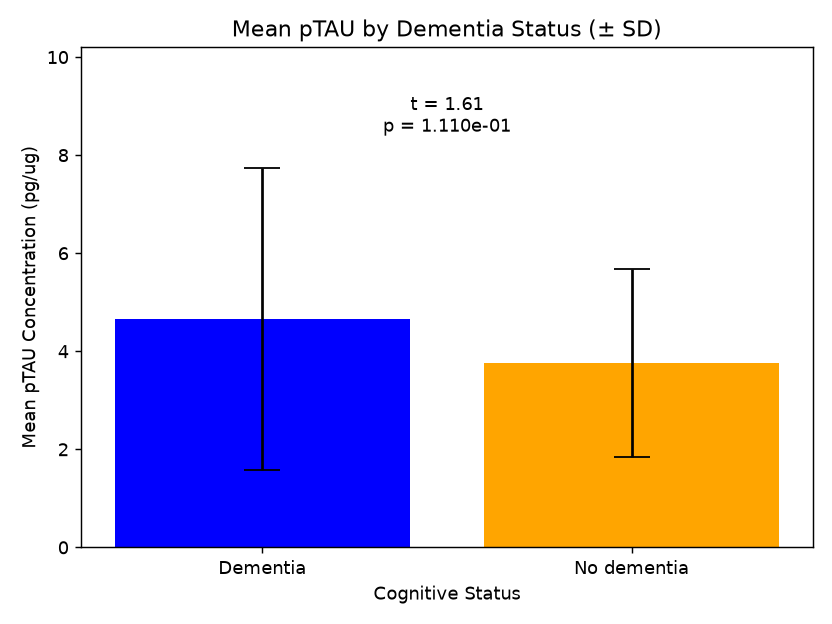

In [2]:
import matplotlib.pyplot as plt
import statistics
from scipy import stats

Patient.instantiate_from_csv("Metadata and Protein Data for Module 1.csv")

#this sorts and prints patients from lowest to highest pTAU concentration
Patient.all_patients.sort(key=Patient.get_ptau, reverse=False)
print("Patients sorted by pTAU concentration:")
for patient in Patient.all_patients:
    print(patient)

#this filters and prints patients using sex and cognitive status
print("\nFemale patients with dementia:")
female_dementia_patients = Patient.filter(
    Patient.all_patients, sex="Female", cognitive_status="Dementia",
    print_patients=True
)
print(f'Number of female patients with dementia = {len(female_dementia_patients)}')

#these lists hold pTAU concentrations 
ptau_dementia = []
ptau_no_dementia = []

for patient in Patient.filter(Patient.all_patients, cognitive_status="Dementia"):
    ptau_dementia.append(patient.ptau)
for patient in Patient.filter(Patient.all_patients, cognitive_status="No dementia"):
    ptau_no_dementia.append(patient.ptau)

#this tests if mean pTAU differs between donors with and without dementia
t_stat, p_val = stats.ttest_ind(ptau_dementia, ptau_no_dementia)
print(f't_stat = {t_stat}, p_val = {p_val}')

#this calculates the standard deviation for each group
x_dementia_bar = statistics.mean(ptau_dementia)
x_no_dementia_bar = statistics.mean(ptau_no_dementia)
ptau_dementia_stdev = statistics.stdev(ptau_dementia)
ptau_no_dementia_stdev = statistics.stdev(ptau_no_dementia)

print(f'\nDementia: n = {len(ptau_dementia)}, mean = {x_dementia_bar:.3f}, SD = {ptau_dementia_stdev:.3f} pg/ug')
print(f'No dementia: n = {len(ptau_no_dementia)}, mean = {x_no_dementia_bar:.3f}, SD = {ptau_no_dementia_stdev:.3f} pg/ug')
print(f'Mean difference (dementia - no dementia) = {x_dementia_bar - x_no_dementia_bar:.3f} pg/ug')

#this bar graph compares pTAU between donors 
Patient_status_cols = ['Dementia', 'No dementia']
mean_status = [x_dementia_bar, x_no_dementia_bar]
stdev_status = [ptau_dementia_stdev, ptau_no_dementia_stdev]

plt.figure()
plt.bar(Patient_status_cols, mean_status, yerr=stdev_status,
        capsize=10, color=["blue", "orange"])
plt.title("Mean pTAU by Dementia Status (± SD)")
plt.xlabel("Cognitive Status")
plt.ylabel("Mean pTAU Concentration (pg/ug)")
#this displays the t-test results above the bars, following the example
y_max = max(mean_status) + max(stdev_status) * 1.2
plt.text(
    0.5, y_max,
    f't = {t_stat:.2f}\np = {p_val:.3e}',
    ha='center',
    va='bottom'
)
plt.ylim(0, y_max + max(stdev_status) * .6)
plt.tight_layout()
plt.show()



The mean pTAU was 4.658 pg/ug for donors with dementia and 3.756 pg/ug for donors without dementia. The standard deviations were 3.080 and 1.914 pg/ug. The dementia group’s mean was 0.901 pg/ug higher. However, the t-test gave t(82) = 1.611 and p = 0.111. Since the p-value was above 0.05, the difference was not statistically significant. This does not mean the groups are exactly the same, but there was not enough evidence to say their means were different.

Female vs. male donors with dementia: t_stat = 0.6156094973860969, p_val = 0.5416394440205926

Female donors with dementia: n = 27, mean = 4.877, SD = 2.796 pg/ug
Male donors with dementia: n = 15, mean = 4.262, SD = 3.605 pg/ug


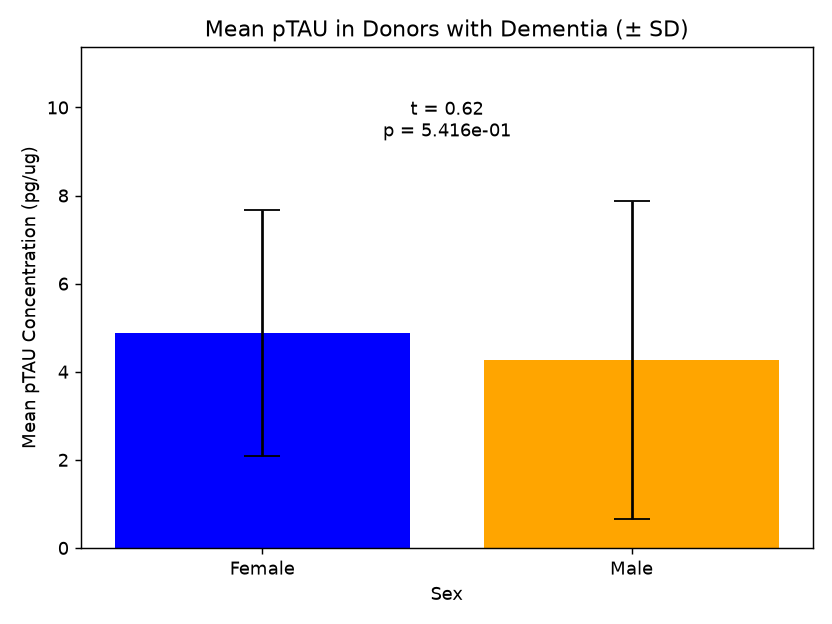

In [3]:
#these lists hold pTAU for female and male donors with dementia
ptau_female = []
ptau_male = []

for patient in Patient.filter(Patient.all_patients, sex="Female", cognitive_status="Dementia"):
    ptau_female.append(patient.ptau)
for patient in Patient.filter(Patient.all_patients, sex="Male", cognitive_status="Dementia"):
    ptau_male.append(patient.ptau)

#this tests if mean pTAU differs between female and male donors with dementia
t_stat_sex, p_val_sex = stats.ttest_ind(ptau_female, ptau_male)
print(f'Female vs. male donors with dementia: t_stat = {t_stat_sex}, p_val = {p_val_sex}')

#this calculates the mean and sample standard deviation for each sex
x_female_bar = statistics.mean(ptau_female)
x_male_bar = statistics.mean(ptau_male)
ptau_female_stdev = statistics.stdev(ptau_female)
ptau_male_stdev = statistics.stdev(ptau_male)

print(f'\nFemale donors with dementia: n = {len(ptau_female)}, mean = {x_female_bar:.3f}, SD = {ptau_female_stdev:.3f} pg/ug')
print(f'Male donors with dementia: n = {len(ptau_male)}, mean = {x_male_bar:.3f}, SD = {ptau_male_stdev:.3f} pg/ug')

#this bar graph compares female and male donors as required in the assignment
Patient_sex_cols = ['Female', 'Male']
mean_sex = [x_female_bar, x_male_bar]
stdev_sex = [ptau_female_stdev, ptau_male_stdev]

plt.figure()
plt.bar(Patient_sex_cols, mean_sex, yerr=stdev_sex,
        capsize=10, color=["blue", "orange"])
plt.title("Mean pTAU in Donors with Dementia (± SD)")
plt.xlabel("Sex")
plt.ylabel("Mean pTAU Concentration (pg/ug)")
#this displays the female-versus-male t-test results above the error bars
y_max_sex = max(mean_sex) + max(stdev_sex) * 1.2
plt.text(
    0.5, y_max_sex,
    f't = {t_stat_sex:.2f}\np = {p_val_sex:.3e}',
    ha='center',
    va='bottom'
)
#this leaves enough space for both lines of text
plt.ylim(0, y_max_sex + max(stdev_sex) * .6)
plt.tight_layout()
plt.show()



For donors with dementia, the female group had a mean pTAU of 4.877 pg/ug (SD = 2.796, n = 27). The male group had a mean of 4.262 pg/ug (SD = 3.605, n = 15). The female mean was higher, but the t-test gave t(40) = 0.616 and p = 0.542. This was also above 0.05, so the difference was not statistically significant.

Slope = 0.002152, intercept = 4.062666, R squared = 0.017809, p = 0.226204


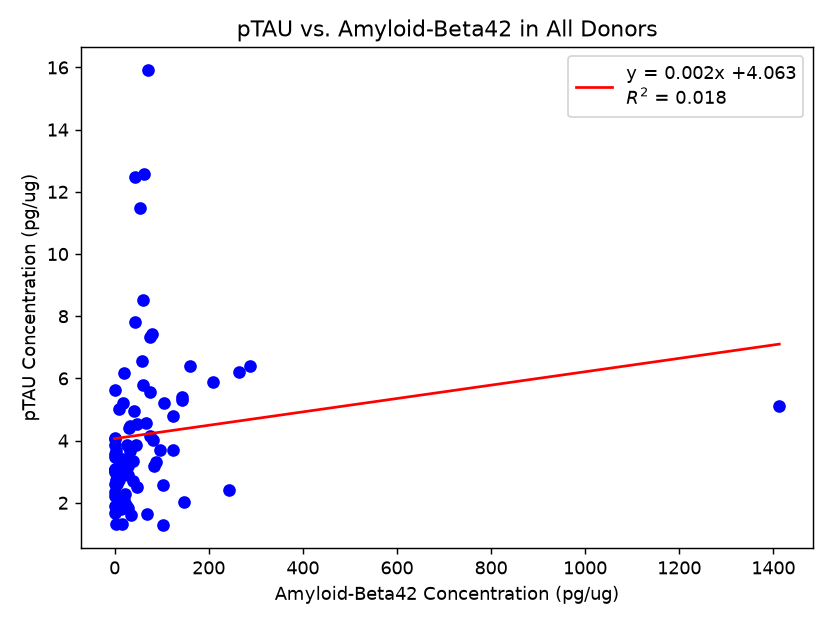

In [4]:
#this collects two continuous measurements from each donor for the scatter plot
patient_abeta42 = []
patient_ptau = []

for patient in Patient.all_patients:
    patient_abeta42.append(patient.abeta42)
    patient_ptau.append(patient.ptau)

#this plots amyloid-beta42 on the x-axis and pTAU on the y-axis
X = patient_abeta42
y = patient_ptau

#this fits a straight line to predict pTAU (y) from amyloid-beta42 (X)
slope, intercept, r_value, regression_p_val, std_err = stats.linregress(X, y)

#for linear regression with an intercept, R squared is the correlation squared
#it describes the fraction of variation in pTAU explained by this fitted line
r_squared = r_value ** 2

#these endpoints draw the regression line across the observed amyloid-beta42 range
line_x = [min(X), max(X)]
line_y = [slope * x + intercept for x in line_x]

plt.figure()
plt.scatter(X, y, color='blue')

#this adds the regression line and shows its equation and R squared in the legend
plt.plot(line_x, line_y, color='red',
         label=f'y = {slope:.3f}x {intercept:+.3f}\n$R^2$ = {r_squared:.3f}')
plt.legend()
plt.xlabel('Amyloid-Beta42 Concentration (pg/ug)')
plt.ylabel('pTAU Concentration (pg/ug)')
plt.title('pTAU vs. Amyloid-Beta42 in All Donors')
plt.tight_layout()
plt.show()
print(f"Slope = {slope:.6f}, intercept = {intercept:.6f}, R squared = {r_squared:.6f}, p = {regression_p_val:.6f}")

The scatter plot had a slight upward trend, but the relationship was weak. The line was pTAU = 0.002152 × amyloid-beta42 + 4.062666, with both proteins measured in pg/ug. R² was 0.018, meaning the line explained about 1.8% of the variation in pTAU. The slope’s p-value was 0.226, so it was not statistically significant. The graph shows a rounded version of the equation. A few donors had much higher amyloid-beta42 values than the others, which could affect the line. This result does not show that one protein caused the other to increase.

## Verify and Validate Your Analysis:
To check the analysis, I checked that all 84 donor IDs were different and that the group counts added up to 84. All donors had numeric values for the two proteins. I also calculated the group means and standard deviations directly from the CSV and compared them with the results from my Patient class. They matched. The main t statistic also matched when calculated using the formula.

I checked the dementia comparison with Welch’s t-test too. This test does not assume equal variances. It gave p = 0.112, so the conclusion did not change. These checks help show that the code is doing the calculations correctly, but they do not check whether the original lab measurements were accurate.

For validation, I compared my results with Gabitto et al. (2024). They found that pTau-bearing cells and amyloid plaques built up more substantially during part of their estimated disease progression, when cognitive problems also increased. My dementia group had higher mean pTAU, which is in the same general direction. However, my difference was not significant (p = 0.111), so my analysis does not confirm their finding. [14](https://doi.org/10.1038/s41593-024-01774-5)

My scatter plot also showed that amyloid-beta42 and pTAU had only a weak linear relationship (R² = 0.018). The paper measured stained brain tissue and used a model of disease progression, while I compared protein concentrations and broad dementia groups. These are different measurements, so the results do not have to match exactly. Also, the class donors appear to come from the same cohort, so this comparison is context rather than an independent check with a new group of people. The original protein assay still needs to be confirmed. [14](https://doi.org/10.1038/s41593-024-01774-5)

In [5]:
#this checks the calculations directly from the CSV
import math
with open("Metadata and Protein Data for Module 1.csv", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))
assert len(rows) == len({row['Donor ID'] for row in rows}) == 84
assert all(math.isfinite(float(row[key])) for row in rows
           for key in ['pTAU pg/ug', 'ABeta42 pg/ug'])
for status, expected in [('Dementia', ptau_dementia), ('No dementia', ptau_no_dementia)]:
    values = [float(row['pTAU pg/ug']) for row in rows if row['Cognitive Status'] == status]
    assert sorted(values) == sorted(expected)
    assert math.isclose(statistics.mean(values), statistics.mean(expected))
    assert math.isclose(statistics.stdev(values), statistics.stdev(expected))
#this calculates the pooled-variance t statistic using its formula
pooled_variance = ((len(ptau_dementia)-1)*statistics.variance(ptau_dementia)
                  + (len(ptau_no_dementia)-1)*statistics.variance(ptau_no_dementia)) / 82
manual_t = (statistics.mean(ptau_dementia)-statistics.mean(ptau_no_dementia)) / math.sqrt(
    pooled_variance*(1/len(ptau_dementia)+1/len(ptau_no_dementia)))
assert math.isclose(manual_t, t_stat)
assert math.isclose(stats.ttest_ind(ptau_female, ptau_male).statistic, t_stat_sex)
print("Data and calculation checks passed.")
print(f"Welch's t-test for dementia status: p = {stats.ttest_ind(ptau_dementia, ptau_no_dementia, equal_var=False).pvalue:.6f}")

Data and calculation checks passed.
Welch's t-test for dementia status: p = 0.111738


## Conclusions and Ethical Implications:
The donors with dementia had higher mean pTAU than the donors without dementia, but the difference was not statistically significant. Female donors with dementia also had a higher mean than male donors with dementia, but this difference was not significant either. The scatter plot showed only a weak relationship between amyloid-beta42 and pTAU. Overall, my results did not give enough evidence to say that mean pTAU differed between the groups.

These results should not be used to diagnose someone. A group average does not describe every person, and dementia can have different causes. Donor information should also be kept private, and the data should be used in ways allowed by the donors’ consent. The CSV lists 81 of the 84 donors as White, so this sample may not represent other populations well. It would not be fair to make broad claims about race or sex based on these results. (Course CSV, n.d.; reference 15)

Based on these results, I would recommend using pTAU together with other information in future research instead of using it alone to separate donors with and without dementia. The mean difference was only 0.901 pg/ug compared with standard deviations of 3.080 and 1.914 pg/ug, and the p-value was above 0.05. The regression also explained only 1.8% of the variation. A larger and more representative study would help check whether these patterns hold. This analysis did not test diagnostic accuracy, so I would not recommend a diagnostic cutoff from these data.

## Limitations and Future Work:
One limitation is that there are only 84 donors, and they are all older adults. The measurements are from donors at death, so they do not show how protein levels changed over time. Also, having dementia is not the same as having a confirmed Alzheimer’s diagnosis. Age, APOE genotype, education, and other diseases could affect the results, but I did not account for them in these comparisons.

The t-tests assume that donors are independent and that the groups have equal variances. The bar graphs do not show each donor’s value or whether the data is skewed. A few high amyloid-beta42 values could also affect the regression line. I made more than one comparison without adjusting for multiple testing, so these results should be treated as exploratory.

For future work, I would confirm how and where the protein measurements were taken. I would add dot plots or box plots to show the individual values and look more closely at unusual values in the scatter plot. I would also check the regression residuals, add confidence intervals, and use Welch’s test for both comparisons. If a straight line does not fit well, I could try a rank-based correlation. Using more donors from different backgrounds and accounting for age and APOE genotype would help make the analysis stronger.

## NOTES FROM YOUR TEAM:
The notebook includes dementia-status comparison, the female-versus-male comparison within dementia, and the amyloid-beta42/pTAU scatter plot.

AI assistance acknowledgment: OpenAI’s Codex helped cite sources, organize the existing Python code into runnable notebook cells, check calculations, and compare the notebook with the rubric. September 25, 2026.

## QUESTIONS FOR YOUR TA:


## References:

1. [WHO, Dementia](https://www.who.int/news-room/fact-sheets/detail/dementia).

2. [Alzheimer’s Association, 2026 Facts and Figures](https://www.alz.org/alzheimers-dementia/facts-figures).

3. [NIA, Alzheimer’s Disease Genetics Fact Sheet](https://www.nia.nih.gov/health/alzheimers-disease-genetics-fact-sheet).

4. [CDC, Modifiable Risk Factors for Alzheimer Disease and Related Dementias](https://stacks.cdc.gov/view/cdc/118011).

5. [CDC, Non-Medical Factors that Affect Dementia Risk](https://www.cdc.gov/alzheimers-dementia/php/sdoh/index.html).

6. [NIA, Alzheimer’s Disease Fact Sheet](https://www.nia.nih.gov/health/alzheimers-and-dementia/alzheimers-disease-fact-sheet).

7. [NIA, How Biomarkers Help Diagnose Dementia](https://www.nia.nih.gov/health/alzheimers-symptoms-and-diagnosis/how-biomarkers-help-diagnose-dementia).

8. [NIA, How Is Alzheimer’s Disease Treated?](https://www.nia.nih.gov/es/node/20473).

9. [FDA, Approval of Kisunla](https://www.fda.gov/drugs/news-events-human-drugs/fda-approves-treatment-adults-alzheimers-disease).

10. [Medicare, Monoclonal Antibodies for Early Alzheimer’s](https://www.medicare.gov/coverage/monoclonal-antibodies-for-treating-early-alzheimers-disease).

11. [NIA, What Happens to the Brain in Alzheimer’s Disease?](https://www.nia.nih.gov/health/what-happens-brain-alzheimers-disease).

12. [NIA, Active Alzheimer’s and Related Dementias Clinical Trials](https://www.nia.nih.gov/research/ongoing-AD-trials).

13. [SEA-AD: A multimodal cellular atlas and resource for Alzheimer’s disease (2024)](https://pmc.ncbi.nlm.nih.gov/articles/PMC11577961/).

14. [Gabitto et al., Integrated multimodal cell atlas of Alzheimer’s disease (2024)](https://doi.org/10.1038/s41593-024-01774-5).

15. *[Metadata and Protein Data for Module 1.csv](Metadata%20and%20Protein%20Data%20for%20Module%201.csv)*. (n.d.). [CSV data set provided for the Module 1 course assignment]. Author and original publication date are not listed in the file.
